# 06 — Final comparison

**Goal:** put every model on the same test set and metrics, pick the best, and visualise its forecast. We also report **skill vs the random walk** and **directional accuracy** — the metrics that reveal real forecasting skill at the 1-day horizon.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
# make the models/ folder importable whether the notebook runs from models/ or the repo root
HERE = os.getcwd()
MODELS_DIR = HERE if os.path.exists(os.path.join(HERE, "utils.py")) else os.path.join(HERE, "models")
sys.path.insert(0, MODELS_DIR)
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

## 1. Load every model's saved test predictions

In [2]:
files = sorted(glob.glob(os.path.join(utils.PREDICTIONS_DIR, "*.csv")))
print("found:", [os.path.basename(f) for f in files])

def metrics_from(d):
    m = utils.evaluate(d["actual"], d["pred"])
    mse_m = np.mean((d["pred"] - d["actual"]) ** 2)
    mse_rw = np.mean((d["y_t"] - d["actual"]) ** 2)
    m["skill_vs_RW"] = 1 - mse_m / mse_rw
    m["dir_acc"] = np.mean(np.sign(d["pred"] - d["y_t"]) == np.sign(d["actual"] - d["y_t"]))
    return m

rows = {}
for f in files:
    name = os.path.splitext(os.path.basename(f))[0]
    rows[name] = metrics_from(pd.read_csv(f))

d0 = pd.read_csv(files[0])   # random-walk reference (predict y_t)
rw = utils.evaluate(d0["actual"], d0["y_t"]); rw["skill_vs_RW"] = 0.0
rw["dir_acc"] = float("nan")
rows["RandomWalk(ref)"] = rw

table = pd.DataFrame(rows).T.sort_values("RMSE")
table.round(4)

found: ['arima.csv', 'decision_tree.csv', 'lightgbm.csv', 'linear_regression.csv', 'lstm.csv', 'prophet.csv', 'xgboost.csv']


,MAE,RMSE,MAPE,R2,skill_vs_RW,dir_acc
lstm,1.3498,2.1047,1.0426,0.9923,0.0027,0.5758
arima,1.3554,2.1075,1.0472,0.9923,0.0000,0.3636
RandomWalk(ref),1.3554,2.1075,1.0472,0.9923,0.0000,NaN
decision_tree,1.3540,2.1089,1.0455,0.9923,-0.0013,0.5675
lightgbm,1.4872,2.1848,1.1478,0.9917,-0.0747,0.4353
linear_regression,1.7158,2.4051,1.2944,0.9900,-0.3024,0.4573
xgboost,1.7727,2.4528,1.3691,0.9896,-0.3546,0.4353
prophet,4.0509,5.9487,3.0677,0.9387,-6.9671,0.4656


## 2. Best model (lowest test RMSE, excluding the reference)

In [3]:
real = table.drop(index="RandomWalk(ref)")
best = real["RMSE"].idxmin()
print("Best model by RMSE:", best)
print(real.round(4).to_string())

Best model by RMSE: lstm
                      MAE    RMSE    MAPE      R2  skill_vs_RW  dir_acc
lstm               1.3498  2.1047  1.0426  0.9923       0.0027   0.5758
arima              1.3554  2.1075  1.0472  0.9923       0.0000   0.3636
decision_tree      1.3540  2.1089  1.0455  0.9923      -0.0013   0.5675
lightgbm           1.4872  2.1848  1.1478  0.9917      -0.0747   0.4353
linear_regression  1.7158  2.4051  1.2944  0.9900      -0.3024   0.4573
xgboost            1.7727  2.4528  1.3691  0.9896      -0.3546   0.4353
prophet            4.0509  5.9487  3.0677  0.9387      -6.9671   0.4656


## 3. Real vs predicted — best model

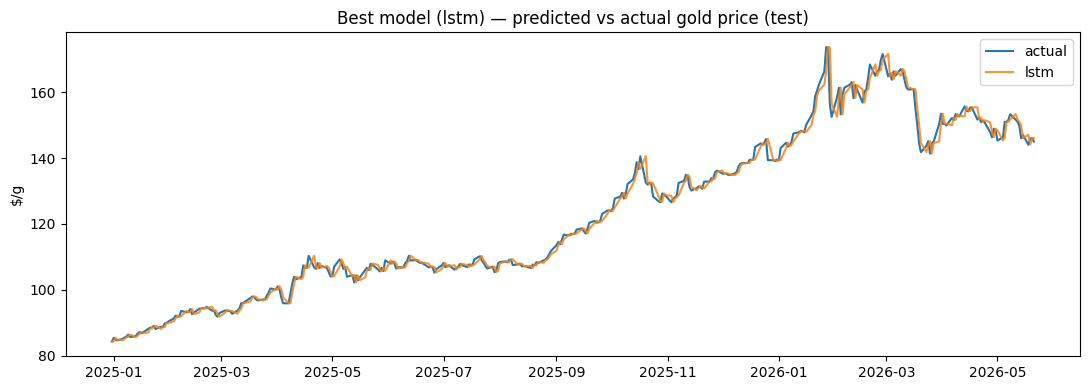

In [4]:
db = pd.read_csv(os.path.join(utils.PREDICTIONS_DIR, f"{best}.csv"), parse_dates=["date"])
plt.figure(figsize=(11, 4))
plt.plot(db["date"], db["actual"], label="actual")
plt.plot(db["date"], db["pred"], label=best, alpha=.85)
plt.title(f"Best model ({best}) — predicted vs actual gold price (test)"); plt.ylabel("$/g")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Save the comparison table + plot to reports/phase3-modeling/

In [5]:
REPORTS = os.path.join(utils._REPO_ROOT, "reports", "phase3-modeling")
os.makedirs(REPORTS, exist_ok=True)

def to_md(t):
    cols = list(t.columns)
    lines = ["| model | " + " | ".join(cols) + " |", "|" + "---|" * (len(cols) + 1)]
    for idx, row in t.iterrows():
        lines.append("| " + idx + " | " + " | ".join(f"{row[c]:.4f}" for c in cols) + " |")
    return "\n".join(lines) + "\n"

table.round(4).to_csv(os.path.join(REPORTS, "comparison_table.csv"))
open(os.path.join(REPORTS, "comparison_table.md"), "w").write(to_md(table.round(4)))

plt.figure(figsize=(11, 4))
plt.plot(db["date"], db["actual"], label="actual")
plt.plot(db["date"], db["pred"], label=best, alpha=.85)
plt.title(f"Best model ({best}) vs actual"); plt.ylabel("$/g"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "best_model_pred_vs_actual.png"), dpi=120); plt.close()
print("saved comparison to", REPORTS)

saved comparison to C:\Users\ibenl\OneDrive\Bureau\Projet PFE\reports\phase3-modeling


## Conclusion
The table ranks every model on identical metrics. The **skill_vs_RW** column is the key read: at a 1-day horizon, values near 0 mean a model barely improves on simply repeating today's price — the expected behaviour for an efficient daily market. The detailed interpretation (why each model behaves as it does, and how to choose by series behaviour) is the subject of the next phase.